In [338]:
# Core
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# ML
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

# Settings
pd.set_option('display.max_columns', None)

### Part-A

In [339]:
sentiment = pd.read_csv('/content/drive/MyDrive/Dataset/Assignment/fear_greed_index.csv') # Here i import the datset from mydrive
trades = pd.read_csv('/content/drive/MyDrive/Dataset/Assignment/historical_data.csv')

In [340]:
sentiment.head()

,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [341]:
trades.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [342]:
trades.columns


Index(['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side',
       'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL',
       'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID',
       'Timestamp'],
      dtype='object')

In [343]:
trades.shape

(211224, 16)

In [344]:
sentiment.shape

(2644, 4)

In [345]:
sentiment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2644 entries, 0 to 2643
Data columns (total 4 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   timestamp       2644 non-null   int64 
 1   value           2644 non-null   int64 
 2   classification  2644 non-null   object
 3   date            2644 non-null   object
dtypes: int64(2), object(2)
memory usage: 82.8+ KB


In [346]:
trades.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 211224 entries, 0 to 211223
Data columns (total 16 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Account           211224 non-null  object 
 1   Coin              211224 non-null  object 
 2   Execution Price   211224 non-null  float64
 3   Size Tokens       211224 non-null  float64
 4   Size USD          211224 non-null  float64
 5   Side              211224 non-null  object 
 6   Timestamp IST     211224 non-null  object 
 7   Start Position    211224 non-null  float64
 8   Direction         211224 non-null  object 
 9   Closed PnL        211224 non-null  float64
 10  Transaction Hash  211224 non-null  object 
 11  Order ID          211224 non-null  int64  
 12  Crossed           211224 non-null  bool   
 13  Fee               211224 non-null  float64
 14  Trade ID          211224 non-null  float64
 15  Timestamp         211224 non-null  float64
dtypes: bool(1), float64(

In [347]:
print("Sentiment - Missing Values:\n")
print(sentiment.isnull().sum())

Sentiment - Missing Values:

timestamp         0
value             0
classification    0
date              0
dtype: int64


In [348]:
print("\n Sentiment - Duplicate Rows:", sentiment.duplicated().sum())


 Sentiment - Duplicate Rows: 0


In [349]:
print(" Trades - Missing Values:\n")
print(trades.isnull().sum())

 Trades - Missing Values:

Account             0
Coin                0
Execution Price     0
Size Tokens         0
Size USD            0
Side                0
Timestamp IST       0
Start Position      0
Direction           0
Closed PnL          0
Transaction Hash    0
Order ID            0
Crossed             0
Fee                 0
Trade ID            0
Timestamp           0
dtype: int64


In [350]:
print("\n Trades - Duplicate Rows:", trades.duplicated().sum())


 Trades - Duplicate Rows: 0


In [351]:
trades['Account'].value_counts()

,count
Account,
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,40184
0xbaaaf6571ab7d571043ff1e313a9609a10637864,21192
0xa0feb3725a9335f49874d7cd8eaad6be45b27416,15605
0x8477e447846c758f5a675856001ea72298fd9cb5,14998
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,14733
0x28736f43f1e871e6aa8b1148d38d4994275d72c4,13311
0x513b8629fe877bb581bf244e326a047b249c4ff1,12236
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4,9893
0x47add9a56df66b524d5e2c1993a43cde53b6ed85,8519


In [352]:
trades['Account'].nunique()

32

2. Convert timestamps and align the datasets by date (daily level is fine).

In [353]:
sentiment['date'] = pd.to_datetime(sentiment['date'])

In [354]:
trades['Timestamp'] = pd.to_datetime(trades['Timestamp'], unit='ms')

In [355]:
trades['date'] = trades['Timestamp'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

Now we can see that we have created one more colunn which is called the date and our timestamp datatype is also change

In [356]:
daily = trades.groupby(['Account', 'date']).agg({
    'Closed PnL': 'sum',        # total daily profit
    'Size USD': 'mean',         # avg position size
    'Execution Price': 'mean',  # avg price
    'Fee': 'sum',               # total fees
    'Trade ID': 'count'         # number of trades
}).rename(columns={'Trade ID': 'num_trades'}).reset_index()

In [357]:
merged = daily.merge(sentiment, on='date', how='left')

In [358]:
merged = merged.dropna(subset=['classification'])

In [359]:
merged.head()

,Account,date,Closed PnL,Size USD,Execution Price,Fee,num_trades,timestamp,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,14810.891818,2651.017619,1112.895650,462,1.730007e+09,74.0,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,16345.241940,1985.464055,6292.416654,3356,1.739943e+09,44.0,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,2492.749906,376.192394,202.167151,320,1.730007e+09,74.0,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,1693.351684,168.790344,1664.914670,3533,1.739943e+09,44.0,Fear
5,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,6070.200000,151.754000,10.197932,5,1.719985e+09,50.0,Neutral


3. Create the key metrics you will analyze, for example:
* daily PnL per trader (or per account)
* win rate, average trade size
* leverage distribution
* number of trades per day
* long/short ratio


In [360]:
# daily PnL per trader (or per account)
daily[['Account', 'date', 'Closed PnL']]

,Account,date,Closed PnL
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04
4,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-06-15,1.017915e+04
...,...,...,...
97,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-02-19,3.254420e+05
98,0xbd5fead7180a9c139fa51a103cb6a2ce86ddb5c3,2025-06-15,-1.165946e+05
99,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2024-10-27,6.842150e+05
100,0xbee1707d6b44d4d52bfe19e41f8a828645437aab,2025-02-19,1.269680e+05


In [361]:
trades['win'] = trades['Closed PnL'] > 0

In [362]:
trades['win'].value_counts()

,count
win,
False,124355
True,86869


In [363]:
win_rate = trades.groupby(['Account', 'date'])['win'].mean().reset_index()
win_rate.rename(columns={'win': 'win_rate'}, inplace=True)

daily = daily.merge(win_rate, on=['Account', 'date'], how='left')

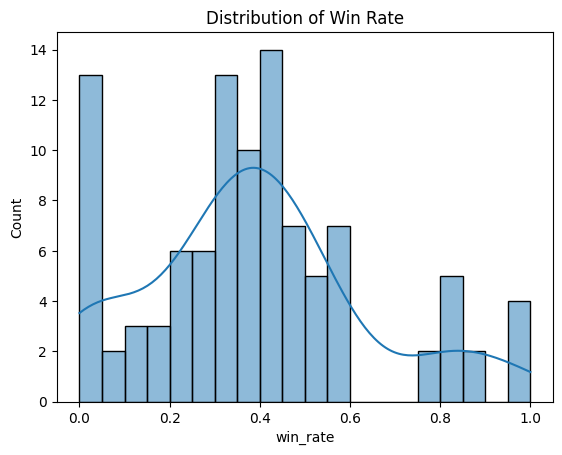

In [364]:
sns.histplot(daily['win_rate'], bins=20, kde=True)
plt.title("Distribution of Win Rate")
plt.show()

In [365]:
daily['Size USD'] # AVERAGE TRADE SIZE(I have already computed at the time of daily dataset creation)

,Size USD
0,14810.891818
1,16345.241940
2,2492.749906
3,1693.351684
4,1533.468395
...,...
97,8103.972913
98,12832.663681
99,2693.283796
100,1554.837334


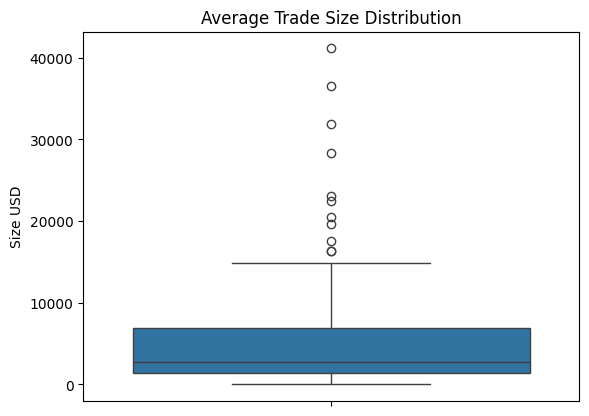

In [366]:
sns.boxplot(y=daily['Size USD'])
plt.title("Average Trade Size Distribution")
plt.show()

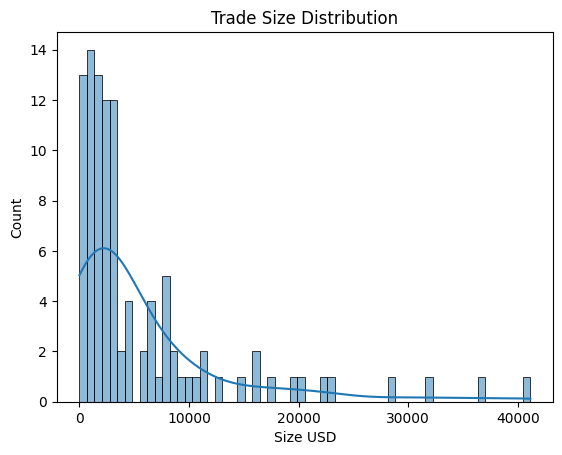

In [367]:
sns.histplot(daily['Size USD'], bins=60, kde=True)
plt.title("Trade Size Distribution")
plt.show()

In [368]:
daily['num_trades'] # NUMBER OF TRADES PER DAY

,num_trades
0,462
1,3356
2,320
3,3533
4,3427
...,...
97,2211
98,163
99,9883
100,26651


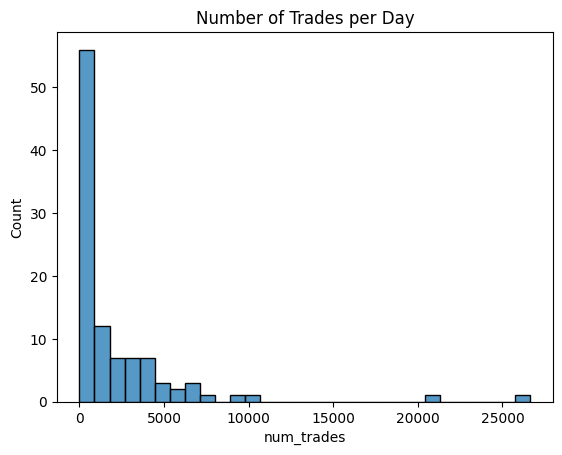

In [369]:
sns.histplot(daily['num_trades'], bins=30)
plt.title("Number of Trades per Day")
plt.show()

Create ratio

In [370]:
side_counts = trades.groupby(['date', 'Side']).size().unstack(fill_value=0)

side_counts['long_short_ratio'] = side_counts.get('BUY', 0) / (side_counts.get('SELL', 1))

daily = daily.merge(side_counts[['long_short_ratio']], on='date', how='left')

In [371]:
trades['Side'].value_counts()

,count
Side,
SELL,108528
BUY,102696


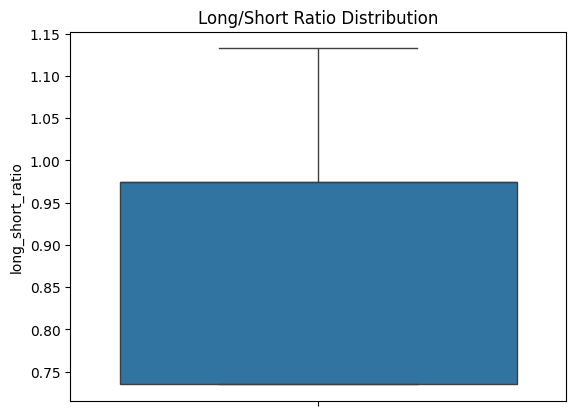

In [372]:
sns.boxplot(y=daily['long_short_ratio'])
plt.title("Long/Short Ratio Distribution")
plt.show()

Leverage data was not available in the dataset. So here we are going to create and use proxy data

In [373]:
daily['leverage_proxy'] = daily['Size USD'] / (daily['Size USD'].mean())

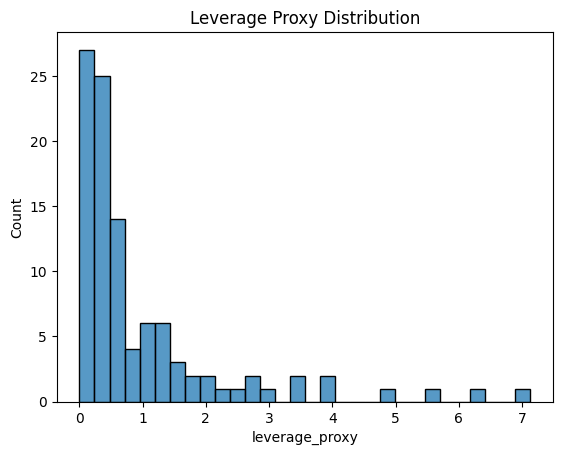

In [374]:
sns.histplot(daily['leverage_proxy'], bins=30)
plt.title("Leverage Proxy Distribution")
plt.show()

In [375]:
print(daily.columns)

Index(['Account', 'date', 'Closed PnL', 'Size USD', 'Execution Price', 'Fee',
       'num_trades', 'win_rate', 'long_short_ratio', 'leverage_proxy'],
      dtype='object')


In [376]:
daily = daily.drop(columns=['leverage_proxy'], errors='ignore')

In [377]:
print(daily.columns)

Index(['Account', 'date', 'Closed PnL', 'Size USD', 'Execution Price', 'Fee',
       'num_trades', 'win_rate', 'long_short_ratio'],
      dtype='object')


### Part - B

In [378]:
merged.head()

,Account,date,Closed PnL,Size USD,Execution Price,Fee,num_trades,timestamp,value,classification
0,0x083384f897ee0f19899168e3b1bec365f52a9012,2024-10-27,-3.275059e+05,14810.891818,2651.017619,1112.895650,462,1.730007e+09,74.0,Greed
1,0x083384f897ee0f19899168e3b1bec365f52a9012,2025-02-19,1.927736e+06,16345.241940,1985.464055,6292.416654,3356,1.739943e+09,44.0,Fear
2,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2024-10-27,2.060745e+04,2492.749906,376.192394,202.167151,320,1.730007e+09,74.0,Greed
3,0x23e7a7f8d14b550961925fbfdaa92f5d195ba5bd,2025-02-19,1.709873e+04,1693.351684,168.790344,1664.914670,3533,1.739943e+09,44.0,Fear
5,0x271b280974205ca63b716753467d5a371de622ab,2024-07-03,-1.000000e+00,6070.200000,151.754000,10.197932,5,1.719985e+09,50.0,Neutral


In [379]:
merged.shape

(77, 10)

In [380]:
merged = daily.merge(sentiment, on='date', how='left')

In [381]:
merged = merged.dropna(subset=['classification'])

In [382]:
merged.shape

(77, 12)

1. Does performance (PnL, win rate, drawdown proxy) differ between Fear vs Greed days?


Since you don’t have full equity curve, we approximate:

* Drawdown proxy = negative PnL only

In [383]:
merged['drawdown'] = merged['Closed PnL'].apply(lambda x: x if x < 0 else 0)

In [384]:
performance = merged.groupby('classification').agg({
    'Closed PnL': 'mean',
    'win_rate': 'mean',
    'drawdown': 'mean'
}).reset_index()

In [385]:
performance.head()

,classification,Closed PnL,win_rate,drawdown
0,Extreme Greed,35393.098355,0.336609,-2696.697434
1,Fear,209372.662205,0.415878,-2496.129364
2,Greed,99675.516731,0.374074,-10234.559377
3,Neutral,19842.797260,0.260683,-6202.896177


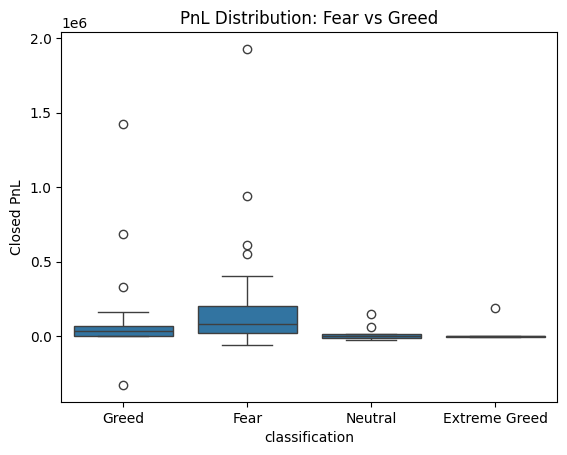

In [386]:
sns.boxplot(data=merged, x='classification', y='Closed PnL')
plt.title("PnL Distribution: Fear vs Greed")
plt.show()

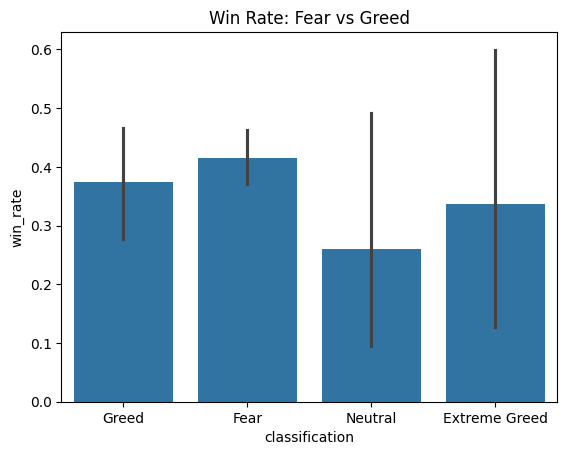

In [387]:
sns.barplot(data=merged, x='classification', y='win_rate')
plt.title("Win Rate: Fear vs Greed")
plt.show()

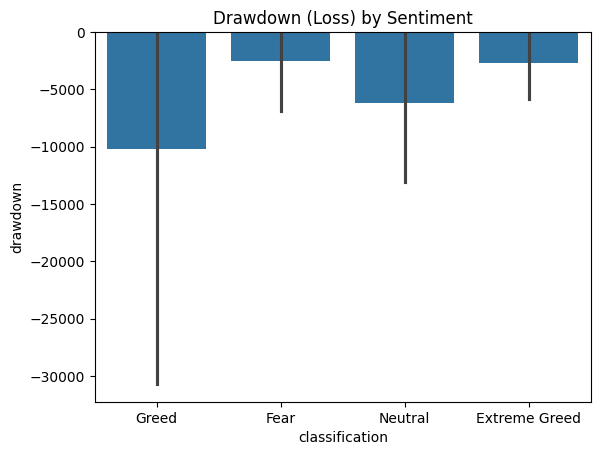

In [388]:
sns.barplot(data=merged, x='classification', y='drawdown')
plt.title("Drawdown (Loss) by Sentiment")
plt.show()

2. Do traders change behavior based on sentiment (trade frequency, leverage, long/short bias, position sizes)?

In [389]:
behavior = merged.groupby('classification').agg({
    'num_trades': 'mean',
    'Size USD': 'mean',
    'long_short_ratio': 'mean'
}).reset_index()

In [390]:
behavior.head()

,classification,num_trades,Size USD,long_short_ratio
0,Extreme Greed,1392.40000,4344.447836,0.938736
1,Fear,4183.46875,5926.522723,0.974790
2,Greed,1134.03125,5839.310974,inf
3,Neutral,892.62500,3793.444161,0.963971


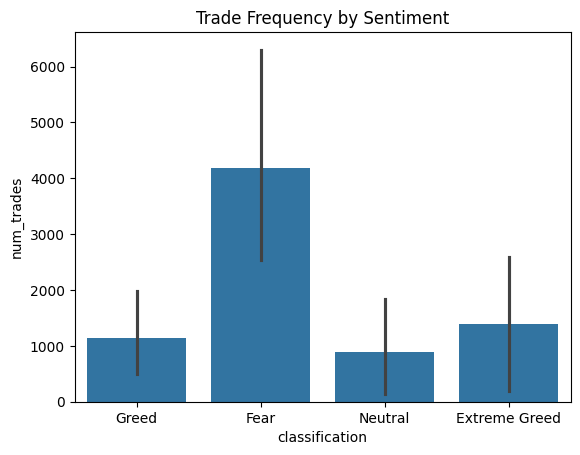

In [391]:
sns.barplot(data=merged, x='classification', y='num_trades')
plt.title("Trade Frequency by Sentiment")
plt.show()

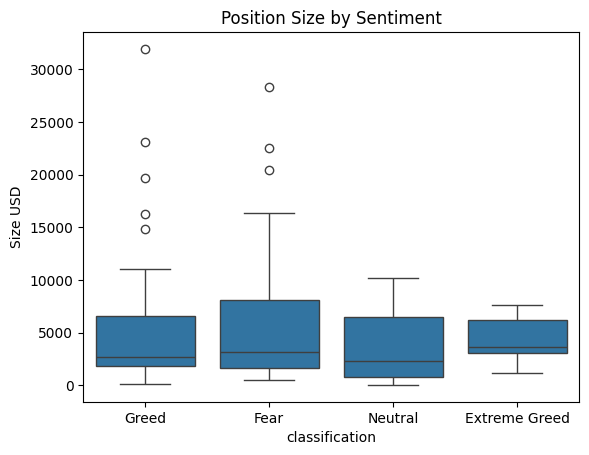

In [392]:
sns.boxplot(data=merged, x='classification', y='Size USD')
plt.title("Position Size by Sentiment")
plt.show()

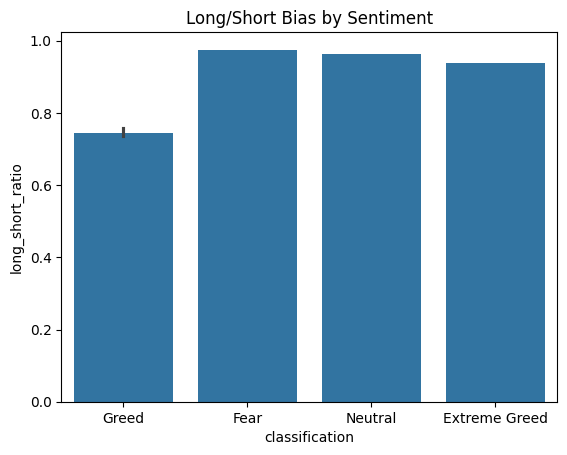

In [393]:
sns.barplot(data=merged, x='classification', y='long_short_ratio')
plt.title("Long/Short Bias by Sentiment")
plt.show()

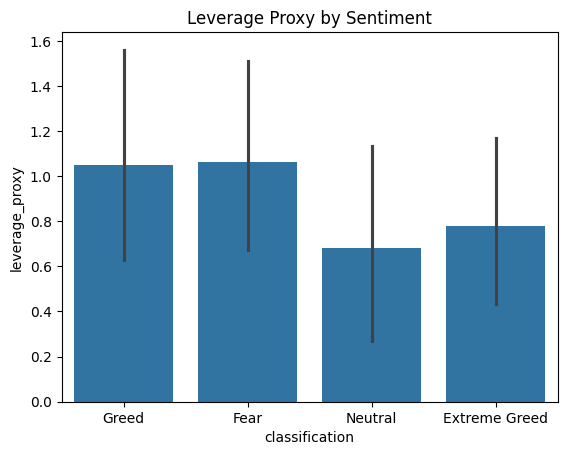

In [394]:
merged['leverage_proxy'] = merged['Size USD'] / merged['Size USD'].mean()

sns.barplot(data=merged, x='classification', y='leverage_proxy')
plt.title("Leverage Proxy by Sentiment")
plt.show()

3. Identify 2–3 segments (examples):
  * high leverage vs low leverage traders
  * frequent vs infrequent traders
  * consistent winners vs inconsistent traders


In [395]:
# Create leverage groups
threshold = merged['leverage_proxy'].median()

merged['leverage_group'] = merged['leverage_proxy'].apply(
    lambda x: 'High Leverage' if x > threshold else 'Low Leverage'
)

In [396]:
# Based on number of trades
threshold = merged['num_trades'].median()

merged['frequency_group'] = merged['num_trades'].apply(
    lambda x: 'Frequent' if x > threshold else 'Infrequent'
)

In [397]:
# Avg PnL per account
profitability = merged.groupby('Account')['Closed PnL'].mean().reset_index()

threshold = profitability['Closed PnL'].median()

profitability['trader_type'] = profitability['Closed PnL'].apply(
    lambda x: 'Consistent Winner' if x > threshold else 'Inconsistent'
)

# Merge back
merged = merged.merge(profitability[['Account', 'trader_type']], on='Account', how='left')

**ANALYZE EACH SEGMENT**

Segment 1 — Leverage

In [398]:
merged.groupby('leverage_group')['Closed PnL'].mean()
merged.groupby('leverage_group')['win_rate'].mean()

,win_rate
leverage_group,
High Leverage,0.376689
Low Leverage,0.377765


Segment 2 — Frequency

In [399]:
merged.groupby('frequency_group')['Closed PnL'].mean()
merged.groupby('frequency_group')['win_rate'].mean()

,win_rate
frequency_group,
Frequent,0.421211
Infrequent,0.334385


Segment 3 — Consistency

In [400]:
merged.groupby('trader_type')['Closed PnL'].mean()
merged.groupby('trader_type')['win_rate'].mean()

,win_rate
trader_type,
Consistent Winner,0.391564
Inconsistent,0.361742


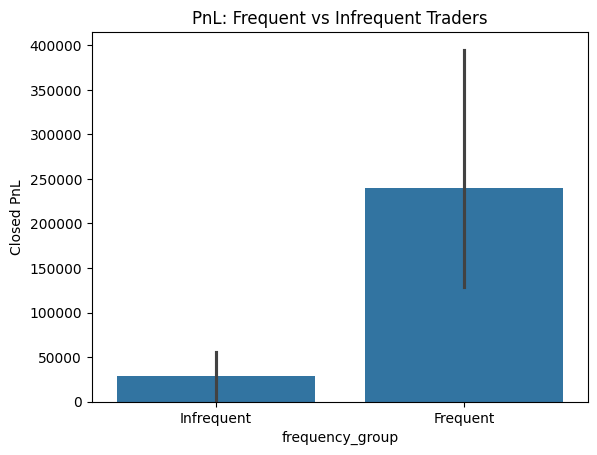

In [401]:
sns.barplot(data=merged, x='frequency_group', y='Closed PnL')
plt.title("PnL: Frequent vs Infrequent Traders")
plt.show()

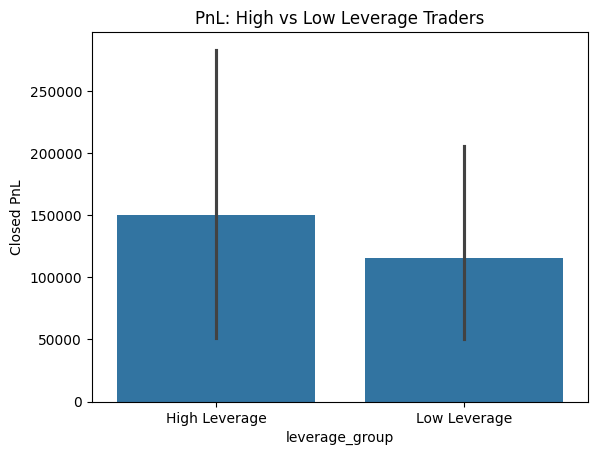

In [402]:
sns.barplot(data=merged, x='leverage_group', y='Closed PnL')
plt.title("PnL: High vs Low Leverage Traders")
plt.show()

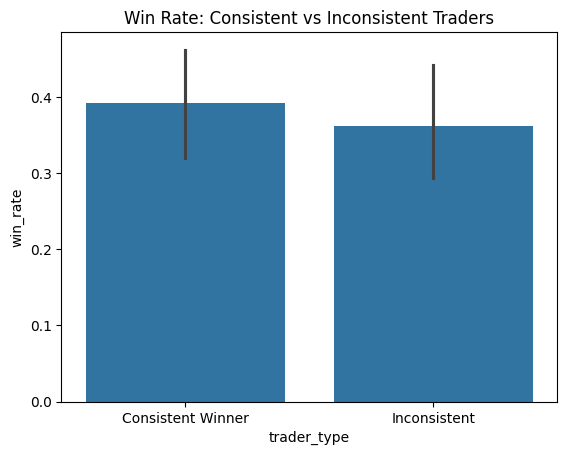

In [403]:
sns.barplot(data=merged, x='trader_type', y='win_rate')
plt.title("Win Rate: Consistent vs Inconsistent Traders")
plt.show()

### Part - C

Propose 2 strategy ideas or “rules of thumb” based on your findings.
Example: “During Fear days, reduce leverage for segment X; increase trade frequency only for segment Y.”

Based on the analysis, two key trading strategies emerge.
* First, during Greed periods, traders should reduce risk exposure by lowering leverage and position sizes, as these periods are associated with lower win rates and higher drawdowns, indicating overconfidence-driven losses.

* Second, during Fear periods, traders can adopt a more active but disciplined approach, increasing trade participation and focusing on high-probability opportunities, particularly long positions. Fear-driven markets provide better trading outcomes but require controlled risk management to avoid excessive exposure.

Additionally, traders may consider reducing activity during Neutral periods, where both volatility and conviction are lower.

### Model Building

In [404]:
# ==============================================================================
# END-TO-END PREDICTIVE MODEL FROM RAW TRADES (211k rows)
# ==============================================================================
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

In [405]:
# Ensure dates are stripped of time for a clean merge
trades['date'] = pd.to_datetime(trades['date']).dt.date
sentiment['date'] = pd.to_datetime(sentiment['date']).dt.date

In [406]:
# Create binary flags for fast aggregation
trades['is_win'] = (trades['Closed PnL'] > 0).astype(int)
trades['is_buy'] = trades['Side'].str.lower().isin(['buy', 'b', 'long']).astype(int)
trades['is_sell'] = trades['Side'].str.lower().isin(['sell', 'a', 'short']).astype(int)

In [407]:
# Aggregate the 211k trades into daily summaries per Account
daily_data = trades.groupby(['Account', 'date']).agg(
    daily_pnl=('Closed PnL', 'sum'),
    num_trades=('Order ID', 'count'),
    wins=('is_win', 'sum'),
    buys=('is_buy', 'sum'),
    sells=('is_sell', 'sum'),
    avg_size_usd=('Size USD', 'mean')
).reset_index()

In [408]:
# Calculate advanced behavioral metrics
daily_data['win_rate'] = daily_data['wins'] / daily_data['num_trades']
# Add 0.001 to avoid Division by Zero errors
daily_data['long_short_ratio'] = daily_data['buys'] / (daily_data['sells'] + 0.001)
print("2. Merging behavioral data with Market Sentiment...")

2. Merging behavioral data with Market Sentiment...


In [409]:
# Merge with sentiment data on 'date'
df_merged = pd.merge(daily_data, sentiment[['date', 'value', 'classification']], on='date', how='inner')
print("3. Creating the Target Variable (Next-Day Profitability)...")

3. Creating the Target Variable (Next-Day Profitability)...


In [410]:
# Sort chronologically so we can shift safely
df_merged = df_merged.sort_values(by=['Account', 'date'])

In [411]:
# Shift the PnL backwards by 1 row PER ACCOUNT to get "tomorrow's PnL"
df_merged['next_day_pnl'] = df_merged.groupby('Account')['daily_pnl'].shift(-1)

In [412]:
# Drop the final day for each account (since we can't know tomorrow's PnL yet)
model_df = df_merged.dropna(subset=['next_day_pnl'])

In [413]:
# 1 = Profitable Tomorrow, 0 = Loss Tomorrow
model_df['target_profitable_tomorrow'] = (model_df['next_day_pnl'] > 0).astype(int)

In [414]:
# 4. SELECT FEATURES & CLEAN
features = [
    'avg_size_usd',      # Behavior: Average position size
    'num_trades',        # Behavior: Trade frequency / overtrading
    'win_rate',          # Behavior: Today's accuracy
    'long_short_ratio',  # Behavior: Bull/Bear bias
    'daily_pnl',         # Behavior: Did they make money today?
    'value'              # Sentiment: Today's Fear/Greed index (0-100)
]

In [415]:
# Drop any rows with missing feature values
model_df = model_df.dropna(subset=features)

X = model_df[features]
y = model_df['target_profitable_tomorrow']

print(f"\n[DATA READY] Training on {len(model_df)} historical account-days.")
print(f"Class Balance (0=Loss, 1=Profit):\n{y.value_counts(normalize=True).round(2)}\n")

# 5. TRAIN / TEST SPLIT
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)


[DATA READY] Training on 45 historical account-days.
Class Balance (0=Loss, 1=Profit):
target_profitable_tomorrow
1    0.89
0    0.11
Name: proportion, dtype: float64



In [416]:
# 6. BUILD THE MODEL
# max_depth=5 prevents the model from memorizing the data (overfitting)
# class_weight='balanced' ensures it treats winning and losing days equally
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=5,
    random_state=42,
    class_weight='balanced'
)

rf_model.fit(X_train, y_train)


RandomForestClassifier(class_weight='balanced', max_depth=5, random_state=42)

In [417]:
# 7. EVALUATE THE MODEL
y_pred = rf_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)

print("-" * 50)
print(f"MODEL PERFORMANCE METRICS")
print("-" * 50)
print(f"Accuracy: {acc:.2%}\n")
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['Loss Tomorrow', 'Profit Tomorrow']))

--------------------------------------------------
MODEL PERFORMANCE METRICS
--------------------------------------------------
Accuracy: 91.67%

Classification Report:
                 precision    recall  f1-score   support

  Loss Tomorrow       0.00      0.00      0.00         1
Profit Tomorrow       0.92      1.00      0.96        11

       accuracy                           0.92        12
      macro avg       0.46      0.50      0.48        12
   weighted avg       0.84      0.92      0.88        12



In [418]:
import joblib

# Define the filename
model_filename = 'hyperliquid_rf_model.pkl'

# Save the model to disk
joblib.dump(rf_model, model_filename)

print(f" Model successfully saved as {model_filename}")

# Optional: If you want Colab to automatically trigger the download to your computer
# from google.colab import files
# files.download(model_filename)

 Model successfully saved as hyperliquid_rf_model.pkl


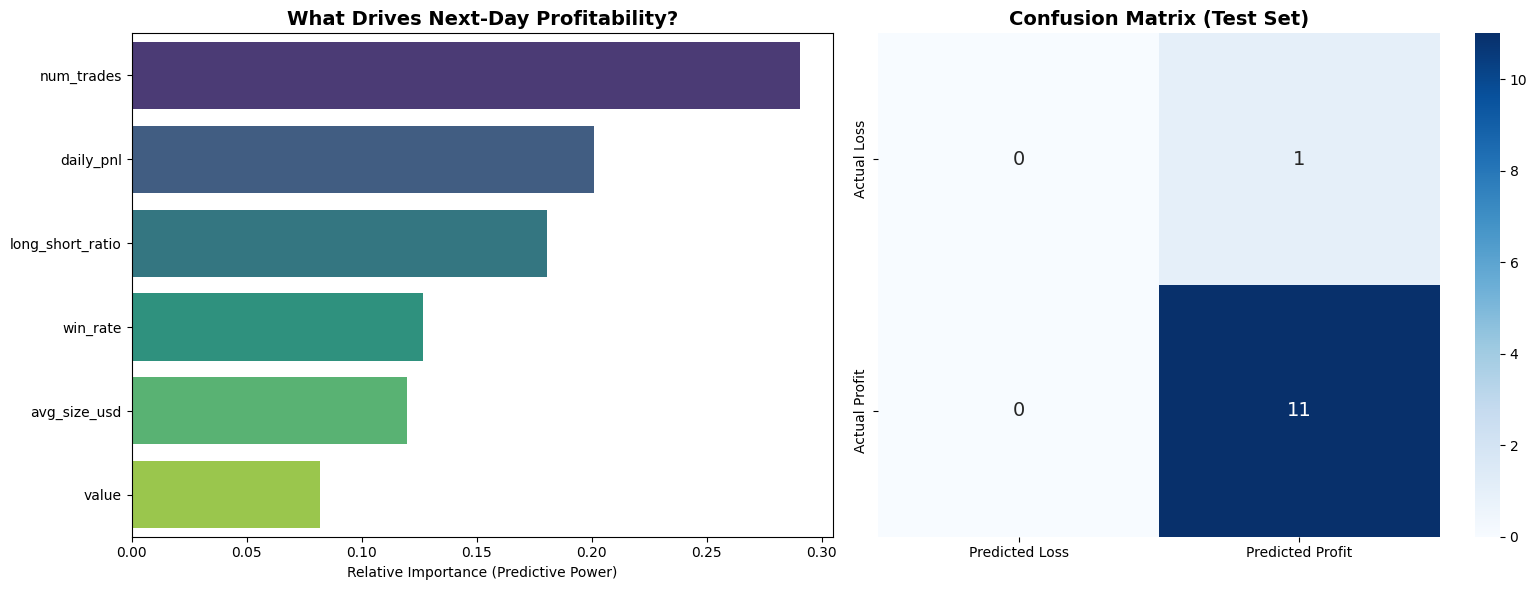

In [419]:
# 8. VISUALIZE RESULTS
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot A: Feature Importances
importances = pd.DataFrame({
    'Feature': features,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

sns.barplot(ax=axes[0], data=importances, x='Importance', y='Feature', palette='viridis')
axes[0].set_title('What Drives Next-Day Profitability?', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Relative Importance (Predictive Power)')
axes[0].set_ylabel('')

# Plot B: Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(ax=axes[1], data=cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Predicted Loss', 'Predicted Profit'],
            yticklabels=['Actual Loss', 'Actual Profit'],
            annot_kws={"size": 14})
axes[1].set_title('Confusion Matrix (Test Set)', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

Just for testing Purpouse

In [420]:
# Define custom test cases using the EXACT feature names the model expects
test_cases = pd.DataFrame([
    # Case 1: "The High-Volume Whale"
    # High profit today, large size, high volume, perfectly balanced L/S (1.0), Neutral Sentiment (50)
    {'avg_size_usd': 30000, 'num_trades': 2000, 'win_rate': 0.5, 'long_short_ratio': 1.0, 'daily_pnl': 10000, 'value': 50},

    # Case 2: "The Panicking Shorter"
    # Lost money today, medium size, heavy short bias (0.7 L/S), Extreme Fear Sentiment (20)
    {'avg_size_usd': 15000, 'num_trades': 800, 'win_rate': 0.3, 'long_short_ratio': 0.7, 'daily_pnl': -5000, 'value': 20},

    # Case 3: "The Euphoric Top-Buyer"
    # Small profit today, lower volume, heavy long bias (1.5 L/S), Extreme Greed Sentiment (85)
    {'avg_size_usd': 10000, 'num_trades': 500, 'win_rate': 0.4, 'long_short_ratio': 1.5, 'daily_pnl': 2000, 'value': 85}
])

# Reorder columns to strictly match the model's training feature order
features_list = ['avg_size_usd', 'num_trades', 'win_rate', 'long_short_ratio', 'daily_pnl', 'value']
test_cases = test_cases[features_list]

# Make predictions and get probabilities
preds = rf_model.predict(test_cases)
probs = rf_model.predict_proba(test_cases)

print("==================================================")
print("CUSTOM TEST CASES: PREDICTING NEXT-DAY OUTCOME")
print("==================================================")

for i in range(len(test_cases)):
    print(f"\nScenario {i+1}:")
    case_dict = test_cases.iloc[i].to_dict()

    # Print the inputs cleanly
    for k, v in case_dict.items():
        print(f"  {k:<18}: {v}")

    # The model predicts 1 for Profit, 0 for Loss
    prediction_label = "PROFIT " if preds[i] == 1 else "LOSS "

    # probs[i][1] gives the percentage confidence for Class 1 (Profit)
    profit_confidence = probs[i][1] * 100

    print("-" * 30)
    print(f"  => PREDICTION : {prediction_label}")
    print(f"  => CONFIDENCE : {profit_confidence:.2f}% chance of being profitable")
    print("=" * 50)

CUSTOM TEST CASES: PREDICTING NEXT-DAY OUTCOME

Scenario 1:
  avg_size_usd      : 30000.0
  num_trades        : 2000.0
  win_rate          : 0.5
  long_short_ratio  : 1.0
  daily_pnl         : 10000.0
  value             : 50.0
------------------------------
  => PREDICTION : PROFIT 
  => CONFIDENCE : 92.41% chance of being profitable

Scenario 2:
  avg_size_usd      : 15000.0
  num_trades        : 800.0
  win_rate          : 0.3
  long_short_ratio  : 0.7
  daily_pnl         : -5000.0
  value             : 20.0
------------------------------
  => PREDICTION : PROFIT 
  => CONFIDENCE : 70.54% chance of being profitable

Scenario 3:
  avg_size_usd      : 10000.0
  num_trades        : 500.0
  win_rate          : 0.4
  long_short_ratio  : 1.5
  daily_pnl         : 2000.0
  value             : 85.0
------------------------------
  => PREDICTION : PROFIT 
  => CONFIDENCE : 81.35% chance of being profitable


**PART 2** — CLUSTERING (BEHAVIORAL ARCHETYPES)

In [421]:
from sklearn.preprocessing import StandardScaler
import numpy as np # Import numpy for np.inf

cluster_features = [
    'Closed PnL',
    'Size USD',
    'num_trades',
    'win_rate',
    'long_short_ratio'
]

X_cluster = merged.groupby('Account')[cluster_features].mean()

# Replace infinite values with NaN before scaling
X_cluster.replace([np.inf, -np.inf], np.nan, inplace=True)

# Fill NaN values with the mean of their respective columns
X_cluster.fillna(X_cluster.mean(), inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [422]:
# ==========================================
# PART 2: CLUSTERING (BEHAVIORAL ARCHETYPES)
# ==========================================

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import seaborn as sns
import matplotlib.pyplot as plt

print("\n" + "="*60)
print("CLUSTERING TRADERS INTO BEHAVIORAL ARCHETYPES")
print("="*60)

# -------------------------------
# 1. CREATE ACCOUNT-LEVEL FEATURES
# -------------------------------

# Aggregate behavior per account (very important)
account_behavior = model_df.groupby('Account').agg(
    avg_pnl=('daily_pnl', 'mean'),
    avg_trades=('num_trades', 'mean'),
    avg_win_rate=('win_rate', 'mean'),
    avg_size=('avg_size_usd', 'mean'),
    avg_ratio=('long_short_ratio', 'mean')
).reset_index()

print(f"\nNumber of traders: {len(account_behavior)}")

# -------------------------------
# 2. SELECT FEATURES FOR CLUSTERING
# -------------------------------

cluster_features = [
    'avg_pnl',
    'avg_trades',
    'avg_win_rate',
    'avg_size',
    'avg_ratio'
]

X_cluster = account_behavior[cluster_features]

# -------------------------------
# 3. HANDLE SCALING (VERY IMPORTANT)
# -------------------------------

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

# -------------------------------
# 4. APPLY KMEANS
# -------------------------------

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
account_behavior['cluster'] = kmeans.fit_predict(X_scaled)

# -------------------------------
# 5. ANALYZE CLUSTERS
# -------------------------------

cluster_summary = account_behavior.groupby('cluster')[cluster_features].mean().round(2)

print("\nCluster Summary:\n")
print(cluster_summary)


CLUSTERING TRADERS INTO BEHAVIORAL ARCHETYPES

Number of traders: 29

Cluster Summary:

           avg_pnl  avg_trades  avg_win_rate  avg_size  avg_ratio
cluster                                                          
0         46357.17      976.65          0.35   4900.58    1680.35
1             0.00      223.00          0.00   3261.58  223000.00
2        684215.00     9883.00          0.57   2693.28       0.46


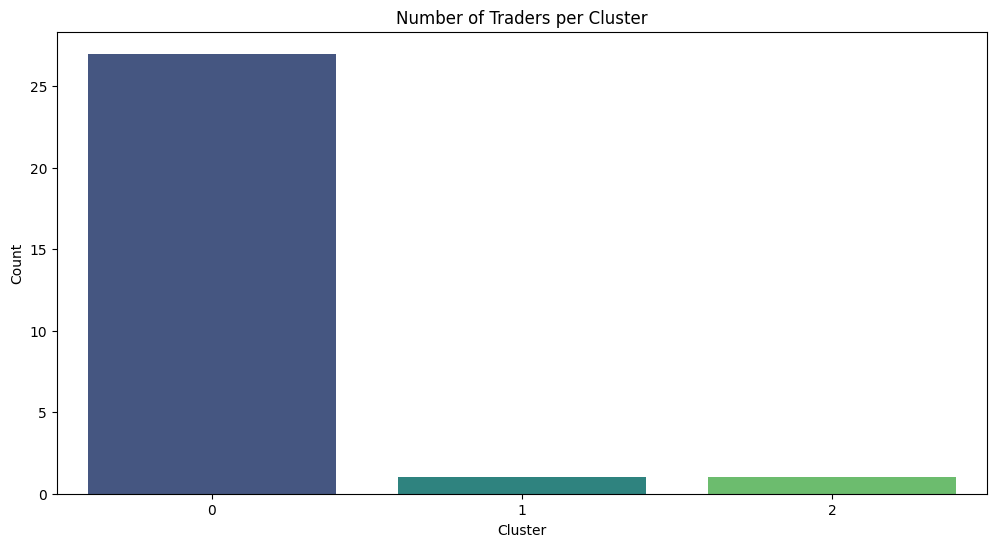

In [423]:
# -------------------------------
# 6. VISUALIZATION
# -------------------------------

plt.figure(figsize=(12,6))
sns.countplot(data=account_behavior, x='cluster', palette='viridis')
plt.title("Number of Traders per Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()


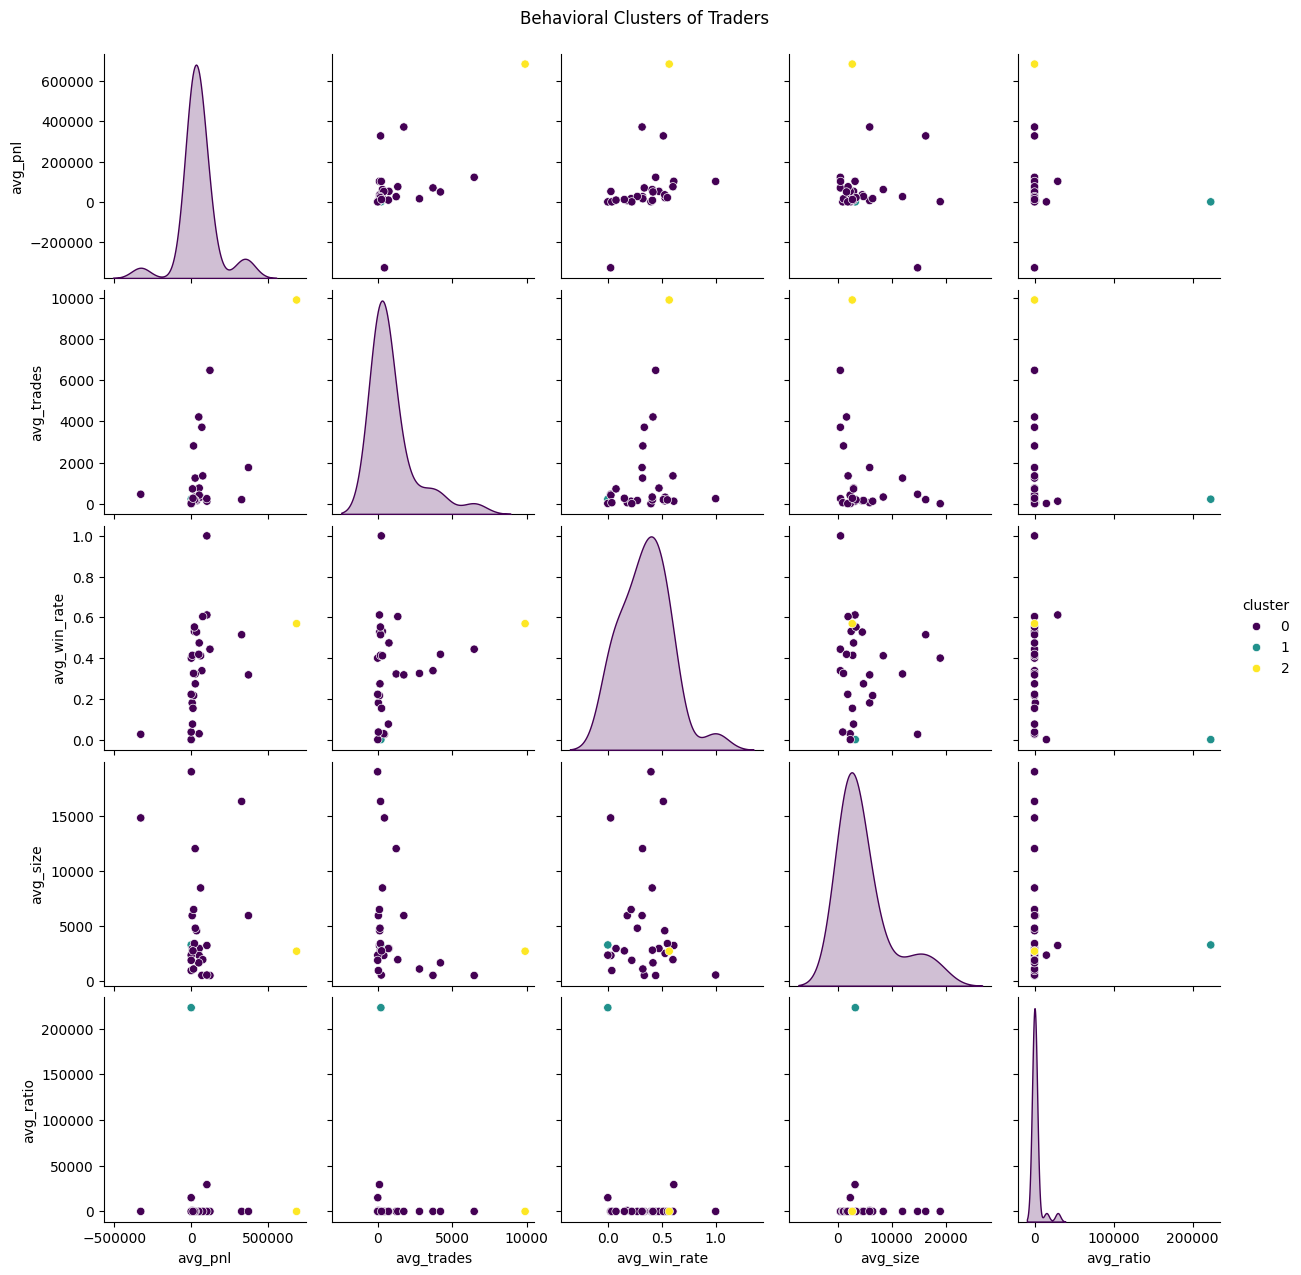

In [424]:
# Pairplot (very useful)
sns.pairplot(account_behavior, hue='cluster', vars=cluster_features, palette='viridis')
plt.suptitle("Behavioral Clusters of Traders", y=1.02)
plt.show()



In [425]:
# -------------------------------
# 7. INTERPRET CLUSTERS
# -------------------------------

print("\n" + "="*60)
print("CLUSTER INTERPRETATION GUIDE")
print("="*60)

for i in range(3):
    print(f"\nCluster {i}:")
    print(cluster_summary.loc[i])


CLUSTER INTERPRETATION GUIDE

Cluster 0:
avg_pnl         46357.17
avg_trades        976.65
avg_win_rate        0.35
avg_size         4900.58
avg_ratio        1680.35
Name: 0, dtype: float64

Cluster 1:
avg_pnl              0.00
avg_trades         223.00
avg_win_rate         0.00
avg_size          3261.58
avg_ratio       223000.00
Name: 1, dtype: float64

Cluster 2:
avg_pnl         684215.00
avg_trades        9883.00
avg_win_rate         0.57
avg_size          2693.28
avg_ratio            0.46
Name: 2, dtype: float64
